In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('AXP_stock_data.csv')

In [9]:
df['Date'] = pd.to_datetime(df['Date'], utc=True)

In [10]:
df.set_index('Date', inplace=True)

We Want to Predict the Next Day Closing Price

In [54]:
trading_days_per_year = 252

In [55]:
df['Target_Next_Close'] = df['Close'].shift(-trading_days_per_year)

In [56]:
df.dropna(inplace=True)

In [57]:
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'MA_50', 'MA_200', 'Daily_Return']
X = df[features]
Y = df ['Target_Next_Close']

In [19]:
# Train-Test Split (80-20%)

In [58]:
split_index = int(len(df) * 0.8)

In [59]:
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
Y_train, Y_test = Y.iloc[:split_index], Y.iloc[split_index:]

In [26]:
# Feature Scaling

In [60]:
scaler = StandardScaler()

In [61]:
X_train_scaled = scaler.fit_transform(X_train)

In [62]:
X_test_scaled = scaler.transform(X_test)

In [34]:
# Initialize and Train the Machine Learning Model (Ridge Regression)

In [63]:
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, Y_train)

Ridge()

In [40]:
# Make Predictions on unseen Test Data

In [64]:
Predictions = model.predict(X_test_scaled)

In [43]:
# Evaluate the Model

In [65]:
rmse = np.sqrt(mean_squared_error(Y_test, Predictions))
mae = mean_absolute_error(Y_test, Predictions)

In [67]:
print(f"Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

Model Evaluation Metrics:
Mean Absolute Error (MAE): $61.52
Root Mean Squared Error (RMSE): $72.70


In [50]:
# Visualize the Results

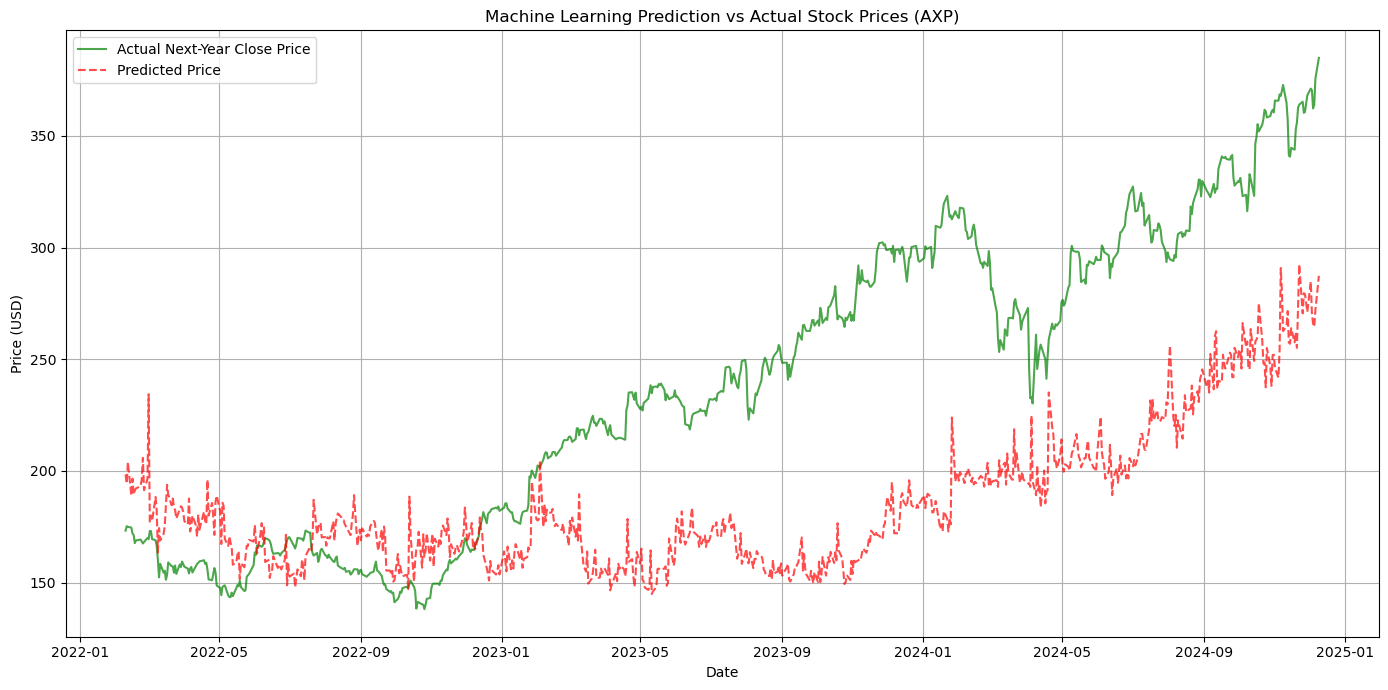

In [69]:
plt.figure(figsize=(14, 7))
plt.plot(Y_test.index, Y_test.values, label='Actual Next-Year Close Price', color='green', alpha=0.7)
plt.plot(Y_test.index, Predictions, label='Predicted Price', color='red', alpha=0.7, linestyle='--')
plt.title('Machine Learning Prediction vs Actual Stock Prices (AXP)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()